# Task-2: Bayesian Change Point Analysis (Brent Returns)

Detect a single structural break in Brent oil daily returns using PyMC: switch point τ, regime means (μ₁, μ₂) and volatilities (σ₁, σ₂), MCMC diagnostics, and quantified before/after impacts. Aligned with the curated event list for narrative context only (no causal claims).

**Kernel:** Select the project's Python interpreter (e.g. **.venv** or **Python (brent-task2)**) via *Select Kernel* so PyMC, ArviZ, and other dependencies are available. If you see *"Unable to start Kernel"* or *"timeout waiting for the ports"*, run `.\scripts\register_kernel.ps1` from the repo root, then choose **Python (brent-task2)** and ensure the workspace setting `jupyter.kernelStartupTimeout` is at least 120 (see `docs/SETUP.md`).

## Setup and paths

In [1]:
import os
import warnings
# Suppress PyTensor g++ warning: set cxx to empty before pytensor is first imported
os.environ.setdefault("PYTENSOR_FLAGS", "cxx=")
# Suppress ArviZ future-refactor warning
warnings.filterwarnings("ignore", message=".*ArviZ.*refactor.*", category=FutureWarning)

import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Repo root
_cwd = Path.cwd()
ROOT = _cwd.parent if (_cwd / ".." / "data" / "processed").resolve().exists() and not (_cwd / "data" / "processed").exists() else _cwd
PROCESSED_DIR = ROOT / "data" / "processed"
EVENTS_DIR = ROOT / "data" / "events"
DOCS_TASK2 = ROOT / "docs" / "task-2"
if not PROCESSED_DIR.exists():
    ROOT = _cwd.parent
    PROCESSED_DIR = ROOT / "data" / "processed"
    EVENTS_DIR = ROOT / "data" / "events"
    DOCS_TASK2 = ROOT / "docs" / "task-2"
assert PROCESSED_DIR.exists(), f"Expected processed dir: {PROCESSED_DIR}"
DOCS_TASK2.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
print("ROOT:", ROOT)
print("Returns:", PROCESSED_DIR / "brent_returns.csv")
print("Events aligned:", PROCESSED_DIR / "events_aligned.csv")

ROOT: e:\brent-oil-structural-break-analysis
Returns: e:\brent-oil-structural-break-analysis\data\processed\brent_returns.csv
Events aligned: e:\brent-oil-structural-break-analysis\data\processed\events_aligned.csv


## 1. Load data and EDA

In [2]:
returns_df = pd.read_csv(PROCESSED_DIR / "brent_returns.csv")
returns_df["Date"] = pd.to_datetime(returns_df["Date"])
returns_df = returns_df.dropna()
returns_df = returns_df.sort_values("Date").reset_index(drop=True)

# Use numpy arrays so type checkers and matplotlib get consistent types
y_full = np.asarray(returns_df["price"], dtype=np.float64)
dates_full = np.asarray(returns_df["Date"], dtype="datetime64[ns]")
# Subsample for faster PyMC run (step=1 uses full data, slower)
SUBSAMPLE_STEP = 5
y = y_full[::SUBSAMPLE_STEP]
dates = dates_full[::SUBSAMPLE_STEP]
n = len(y)
print("Observations (after subsample step {}):".format(SUBSAMPLE_STEP), n)
print("Date range:", dates[0], "to", dates[-1])
print("Return stats:", float(np.mean(y)), float(np.std(y)))

Observations (after subsample step 5): 1802
Date range: 1987-05-21T00:00:00.000000000 to 2022-11-08T00:00:00.000000000
Return stats: 0.0007932547511922513 0.024402515968625492


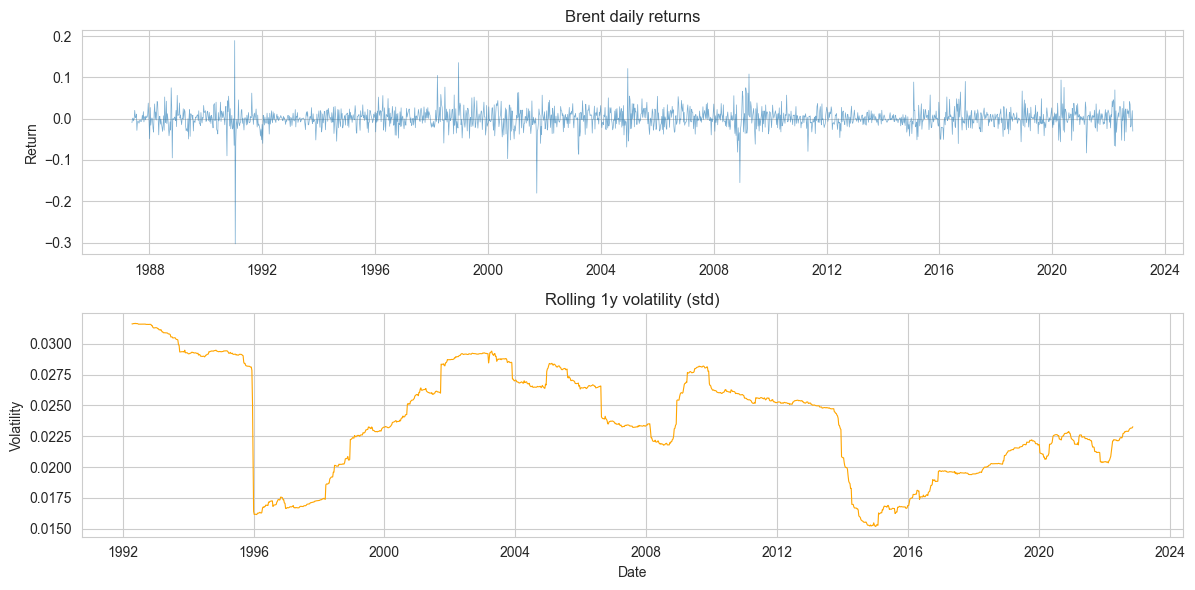

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(dates, y, alpha=0.6, linewidth=0.5)
axes[0].set_title("Brent daily returns")
axes[0].set_ylabel("Return")
roll = pd.Series(y, dtype=np.float64).rolling(252).std()
roll_arr = np.asarray(roll, dtype=np.float64)
axes[1].plot(dates, roll_arr, color="orange", linewidth=0.8)
axes[1].set_title("Rolling 1y volatility (std)")
axes[1].set_ylabel("Volatility")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(DOCS_TASK2 / "returns_and_volatility.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Bayesian change point model (PyMC)

Single break: observations \(t < \tau\) from \(\mathcal{N}(\mu_1, \sigma_1)\), \(t \geq \tau\) from \(\mathcal{N}(\mu_2, \sigma_2)\). We use a **continuous** \(\tau\) in \([1, T-1]\) so that NUTS can sample it; we report the posterior as a date.

In [4]:
import pymc as pm
import arviz as az
import pytensor.tensor as at

with pm.Model() as cp_model:
    # Continuous change point index in (1, n-1)
    tau = pm.Uniform("tau", lower=1.0, upper=float(n - 1))
    # Regime means (returns are roughly centered)
    mu_1 = pm.Normal("mu_1", mu=0.0, sigma=0.1)
    mu_2 = pm.Normal("mu_2", mu=0.0, sigma=0.1)
    # Regime volatilities (positive)
    sigma_1 = pm.HalfNormal("sigma_1", sigma=0.05)
    sigma_2 = pm.HalfNormal("sigma_2", sigma=0.05)
    # Segment means/sigmas per observation (vectorized)
    t_idx = np.arange(n, dtype=np.float64)
    mu_t = at.switch(at.lt(t_idx, tau), mu_1, mu_2)
    sigma_t = at.switch(at.lt(t_idx, tau), sigma_1, sigma_2)
    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu_t, sigma=sigma_t, observed=y)

print(cp_model)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


## 3. Sampling and diagnostics

We use subsampled data (every 5th observation) and 400 tune + 400 draws × 2 chains for a **fast run** so the notebook completes in minutes. For publication or final reports: set `SUBSAMPLE_STEP = 1` in the data cell and use e.g. `draws=1500`, `tune=1500`.

In [ ]:
# Reduced draws/tune and subsampled data keep runtime short; for production: SUBSAMPLE_STEP=1, draws=1500, tune=1500
with cp_model:
    idata = pm.sample(
        draws=400,
        tune=400,
        chains=2,
        target_accept=0.95,
        random_seed=42,
        progressbar=True,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [tau, mu_1, mu_2, sigma_1, sigma_2]


Output()

ValueError: Not enough samples to build a trace.

: 

In [ ]:
summary = az.summary(idata, var_names=["tau", "mu_1", "mu_2", "sigma_1", "sigma_2"])
print(summary)

# Rhat and ESS (use numpy for type-safe attribute access)
rhat = az.rhat(idata)
ess = az.ess(idata)
rhat_max = float(np.max(np.asarray(rhat)))
ess_bulk = np.asarray(ess["bulk_ess"])
print("\nRhat (all < 1.01):", rhat_max < 1.01)
print("ESS bulk (min):", float(np.min(ess_bulk)))

In [ ]:
az.plot_trace(idata, var_names=["tau", "mu_1", "mu_2", "sigma_1", "sigma_2"])
plt.tight_layout()
plt.savefig(DOCS_TASK2 / "trace_plot.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Results and quantified impacts

In [ ]:
# Use idata["posterior"] for type-checker compatibility with ArviZ InferenceData
posterior = idata["posterior"]
tau_post = np.asarray(posterior["tau"]).flatten()
tau_mean = float(np.mean(tau_post))
tau_med = float(np.median(tau_post))
tau_lo, tau_hi = np.percentile(tau_post, [2.5, 97.5])

def index_to_date(idx, dates_arr):
    i = int(np.clip(np.round(idx), 0, len(dates_arr) - 1))
    return pd.Timestamp(dates_arr[i]).strftime("%Y-%m-%d")

break_date_mean = index_to_date(tau_mean, dates)
break_date_med = index_to_date(tau_med, dates)
break_date_lo = index_to_date(tau_lo, dates)
break_date_hi = index_to_date(tau_hi, dates)

print("Posterior change point (index): mean = {:.0f}, median = {:.0f}, 95% CI = [{:.0f}, {:.0f}]".format(tau_mean, tau_med, tau_lo, tau_hi))
print("Break date (mean):", break_date_mean)
print("Break date (median):", break_date_med)
print("95% credible interval (dates):", break_date_lo, "to", break_date_hi)

In [ ]:
posterior = idata["posterior"]
mu_1_post = np.asarray(posterior["mu_1"]).flatten()
mu_2_post = np.asarray(posterior["mu_2"]).flatten()
sigma_1_post = np.asarray(posterior["sigma_1"]).flatten()
sigma_2_post = np.asarray(posterior["sigma_2"]).flatten()

delta_mu = mu_2_post - mu_1_post
ratio_sigma = sigma_2_post / (sigma_1_post + 1e-10)

print("Mean return: before (mu_1) = {:.6f}, after (mu_2) = {:.6f}".format(float(np.mean(mu_1_post)), float(np.mean(mu_2_post))))
print("Change in mean (mu_2 - mu_1): {:.6f} (95% CI: {:.6f} to {:.6f})".format(
    float(np.mean(delta_mu)), float(np.percentile(delta_mu, 2.5)), float(np.percentile(delta_mu, 97.5))))
print("Volatility: sigma_1 = {:.6f}, sigma_2 = {:.6f}".format(float(np.mean(sigma_1_post)), float(np.mean(sigma_2_post))))
print("Volatility ratio (sigma_2/sigma_1): {:.3f} (95% CI: {:.3f} to {:.3f})".format(
    float(np.mean(ratio_sigma)), float(np.percentile(ratio_sigma, 2.5)), float(np.percentile(ratio_sigma, 97.5))))

## 5. Event alignment

In [ ]:
events = pd.read_csv(PROCESSED_DIR / "events_aligned.csv")
events["trading_date"] = pd.to_datetime(events["trading_date"])
break_ts = pd.Timestamp(break_date_med)
events["days_from_break"] = (events["trading_date"] - break_ts).dt.days
near = events.iloc[(events["days_from_break"].abs()).argsort()].head(5)
print("Events nearest to posterior median break date (", break_date_med, "):")
print(near[["short_name", "trading_date", "category", "days_from_break"]].to_string())

## 6. Export for dashboard (Task-3)

In [ ]:
import json

export = {
    "change_point": {
        "index_mean": float(tau_mean),
        "index_median": float(tau_med),
        "index_lo": float(tau_lo),
        "index_hi": float(tau_hi),
        "date_mean": break_date_mean,
        "date_median": break_date_med,
        "date_lo": break_date_lo,
        "date_hi": break_date_hi,
    },
    "regime_before": {
        "mu_mean": float(np.mean(mu_1_post)),
        "mu_sd": float(np.std(mu_1_post)),
        "sigma_mean": float(np.mean(sigma_1_post)),
        "sigma_sd": float(np.std(sigma_1_post)),
    },
    "regime_after": {
        "mu_mean": float(np.mean(mu_2_post)),
        "mu_sd": float(np.std(mu_2_post)),
        "sigma_mean": float(np.mean(sigma_2_post)),
        "sigma_sd": float(np.std(sigma_2_post)),
    },
    "impact": {
        "delta_mu_mean": float(np.mean(delta_mu)),
        "delta_mu_lo": float(np.percentile(delta_mu, 2.5)),
        "delta_mu_hi": float(np.percentile(delta_mu, 97.5)),
        "volatility_ratio_mean": float(np.mean(ratio_sigma)),
        "volatility_ratio_lo": float(np.percentile(ratio_sigma, 2.5)),
        "volatility_ratio_hi": float(np.percentile(ratio_sigma, 97.5)),
    },
    "n_obs": n,
    "date_range": [str(dates[0]), str(dates[-1])],
}

out_path = PROCESSED_DIR / "change_point_posterior.json"
with open(out_path, "w") as f:
    json.dump(export, f, indent=2)
print("Exported:", out_path)

In [ ]:
# Time series of returns with posterior break date (use float for matplotlib axvline/fill_betweenx)
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, y, alpha=0.5, linewidth=0.4, label="Returns")
# Cast to float so axvline(x) and fill_betweenx(x1, x2) get scalar float
t_med: float = float(mdates.date2num(pd.Timestamp(break_date_med)))
t_lo: float = float(mdates.date2num(pd.Timestamp(break_date_lo)))
t_hi: float = float(mdates.date2num(pd.Timestamp(break_date_hi)))
y_min, y_max = float(np.min(y)), float(np.max(y))
ax.axvline(t_med, color="red", linestyle="--", linewidth=1.5, label=f"Break (median): {break_date_med}")
ax.fill_betweenx([y_min, y_max], t_lo, t_hi, alpha=0.2, color="red", label="95% CI")
ax.set_title("Brent returns and posterior change point")
ax.set_ylabel("Return")
ax.legend(loc="upper right")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.savefig(DOCS_TASK2 / "change_point_plot.png", dpi=120, bbox_inches="tight")
plt.show()